# 11 — The Complete VaR Dashboard: Methods, Signals, and Judgment

**Lesson:** Every VaR method has a specific failure mode. By combining multiple methods into one dashboard, the *divergences between methods* become signals — each method's weakness is another method's strength. But numbers can only tell you so much. At some point, judgment takes over.

This is the production dashboard — the culmination of everything we've built.

## Scenario: You are the risk manager

You monitor a £50M multi-asset book. SPY is your largest single exposure at £10M. You have a daily risk meeting at 8am. Before that meeting, you check the dashboard.

Your job is not to predict markets. It's to answer three questions:

1. **Has risk changed since yesterday?**
2. **Is the change meaningful or noise?**
3. **Do I need to act, or can I wait?**

The dashboard helps you answer these. It doesn't answer them for you.

## Parameters

In [1]:
# Parameters
TICKER = "SPY"
START_DATE = "2018-01-01"
END_DATE = None
VAR_WINDOW = 252
VOL_WINDOW = 20
LAMBDA = 0.94
CONFIDENCE = 0.95
POSITION_VALUE = 10_000_000  # £10M SPY position

In [2]:
import sys
sys.path.insert(0, "..")

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

from src.historical_var import historical_var
from src.decay import decay_var
from src.rolling import rolling_var, rolling_decay_var, breach_summary
from yfinance_helpers import download_close_prices, prepare_returns

%matplotlib inline
plt.rcParams["figure.facecolor"] = "white"

In [3]:
prices = download_close_prices(TICKER, start=START_DATE, end=END_DATE)
daily_returns = prepare_returns(prices)

Prepared 2147 daily returns (2018-01-03 to 2026-07-21) from 2148 price observations.


---

## Part A: The complete dashboard

Five methods on one chart: equal-weighted, decay-weighted, vol-scaled, combined, and a 60-day fast window. Each has a distinct failure mode. Together, they form a monitoring system.

In [4]:
# Compute all methods
trailing_vol = daily_returns.rolling(window=VOL_WINDOW).std().clip(lower=0.001)

equal = rolling_var(daily_returns, window=VAR_WINDOW, confidence=CONFIDENCE)
decay = rolling_decay_var(daily_returns, window=VAR_WINDOW, lam=LAMBDA, confidence=CONFIDENCE)
fast60 = rolling_var(daily_returns, window=60, confidence=CONFIDENCE)

# Vol-scaled and combined
first_day = VAR_WINDOW + VOL_WINDOW
print(f"Computing vol-scaled and combined methods (starting day {first_day})...")

volscaled_var, volscaled_breach, volscaled_dates = [], [], []
combined_var, combined_breach, combined_dates = [], [], []

for day in range(first_day, len(daily_returns)):
    wr = daily_returns.iloc[day - VAR_WINDOW : day]
    wi = wr.index
    vc = trailing_vol.loc[wi[-1]]
    vh = trailing_vol.loc[wi].values
    if np.isnan(vh).any():
        continue
    sr = wr.values * (vc / vh)
    vs = historical_var(sr, confidence=CONFIDENCE)
    cb = decay_var(sr[::-1], lam=LAMBDA, confidence=CONFIDENCE)
    nr = daily_returns.iloc[day]
    volscaled_var.append(vs)
    volscaled_breach.append(-nr > vs)
    volscaled_dates.append(daily_returns.index[day])
    combined_var.append(cb)
    combined_breach.append(-nr > cb)
    combined_dates.append(daily_returns.index[day])

volscaled = pd.DataFrame(
    {"VaR": volscaled_var, "Breach": volscaled_breach},
    index=pd.DatetimeIndex(volscaled_dates, name="Date"))
combined = pd.DataFrame(
    {"VaR": combined_var, "Breach": combined_breach},
    index=pd.DatetimeIndex(combined_dates, name="Date"))

print("All methods computed.")

Computing vol-scaled and combined methods (starting day 272)...


All methods computed.


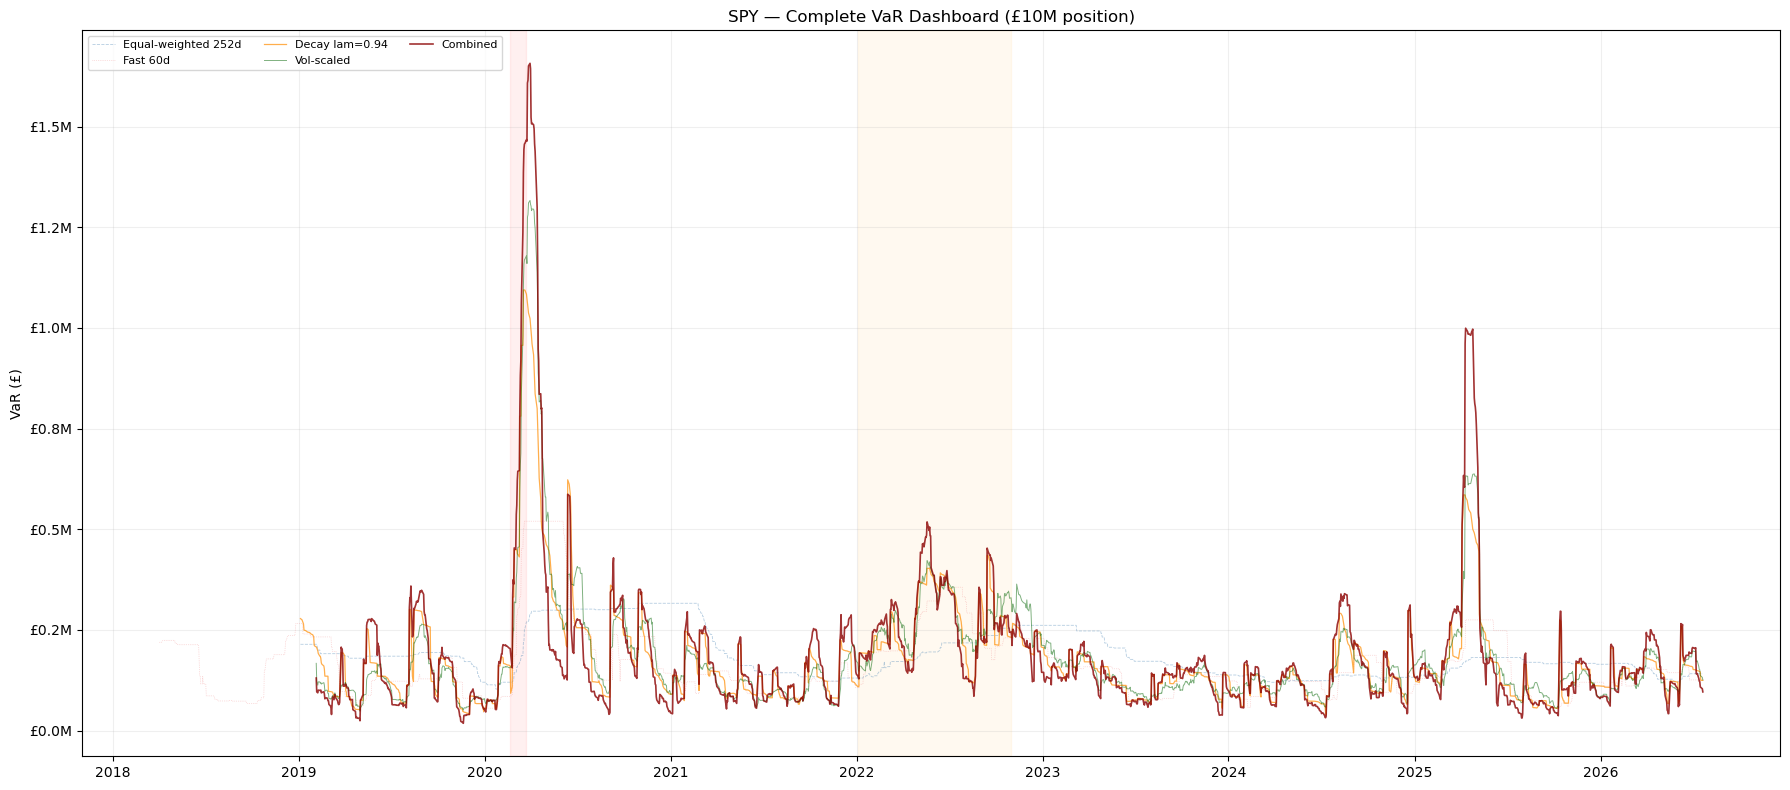

In [5]:
# The complete dashboard
fig, ax = plt.subplots(figsize=(18, 8))

methods = [
    (equal, "Equal-weighted 252d", "steelblue", 0.4, "--", 0.6),
    (fast60, "Fast 60d", "lightcoral", 0.5, ":", 0.5),
    (decay, "Decay lam=0.94", "darkorange", 0.7, "-", 0.9),
    (volscaled, "Vol-scaled", "darkgreen", 0.5, "-", 0.7),
    (combined, "Combined", "darkred", 0.8, "-", 1.2),
]

for res, label, color, alpha, ls, lw in methods:
    ax.plot(res.index, res["VaR"] * POSITION_VALUE, linewidth=lw, color=color,
            alpha=alpha, linestyle=ls, label=label)

ax.axvspan(pd.Timestamp("2020-02-19"), pd.Timestamp("2020-03-23"), alpha=0.06, color="red")
ax.axvspan(pd.Timestamp("2022-01-03"), pd.Timestamp("2022-10-31"), alpha=0.06, color="orange")

ax.set_ylabel(f"VaR (£)")
ax.set_title(f"{TICKER} — Complete VaR Dashboard (£{POSITION_VALUE/1e6:.0f}M position)")
ax.yaxis.set_major_formatter(plt.FuncFormatter(lambda y, _: f'£{y/1e6:.1f}M'))
ax.legend(loc="upper left", ncol=3, fontsize=8)
ax.grid(True, alpha=0.2)
plt.tight_layout()
plt.show()

### What each method tells you

| Method | Role in the dashboard | Failure mode |
|--------|----------------------|-------------|
| Equal 252d | Baseline — what does equal-weighted history say? | Slow to react to regime changes. |
| Fast 60d | Early warning — is something changing RIGHT NOW? | Noisy, prone to false alarms. |
| Decay λ=0.94 | Current risk — what does recent data dominate? | Drops guard too fast during calm. |
| Vol-scaled | Regime context — is it just vol or is shape changing? | Shape-stability assumption. |
| Combined | Best estimate — both ordering and magnitude fixed. | Three parameters, overfitting risk. |

**The dashboard works because no single method dominates in all conditions.** When they agree, risk is unambiguous. When they disagree, something interesting is happening.

---

## Part B: Method divergence as signal

The gaps between methods are information. Let's define three signals.

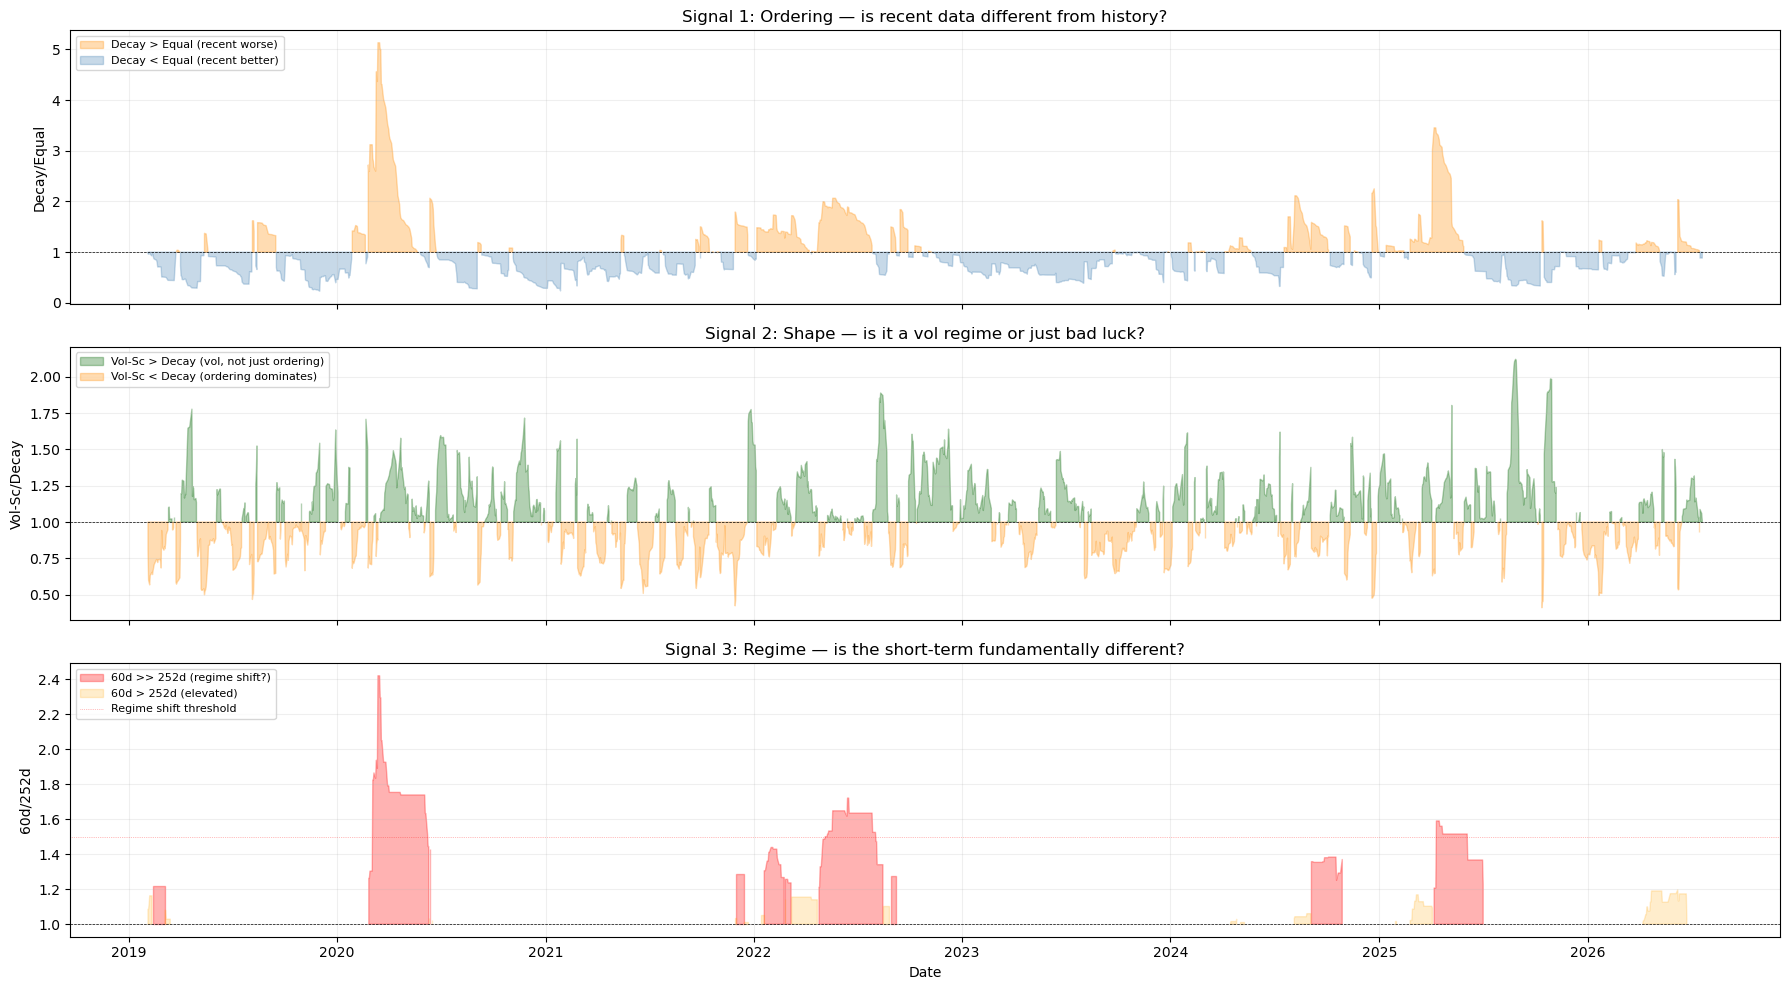

In [6]:
common_idx = equal.index.intersection(decay.index).intersection(volscaled.index)

# Signal 1: Decay vs Equal — is recent data worse than history?
ordering_signal = decay.loc[common_idx, "VaR"] / equal.loc[common_idx, "VaR"]

# Signal 2: Vol-scaled vs Decay — is it just vol or is shape changing?
shape_signal = volscaled.loc[common_idx, "VaR"] / decay.loc[common_idx, "VaR"]

# Signal 3: 60d vs 252d — regime shift detection
common_60 = common_idx.intersection(fast60.index)
regime_signal = fast60.loc[common_60, "VaR"] / equal.loc[common_60, "VaR"]

fig, axes = plt.subplots(3, 1, figsize=(18, 10), sharex=True)

# Top: Ordering — decay vs equal
axes[0].fill_between(ordering_signal.index, 1.0, ordering_signal.values,
                     where=(ordering_signal.values > 1.0), alpha=0.3, color="darkorange",
                     label="Decay > Equal (recent worse)")
axes[0].fill_between(ordering_signal.index, ordering_signal.values, 1.0,
                     where=(ordering_signal.values < 1.0), alpha=0.3, color="steelblue",
                     label="Decay < Equal (recent better)")
axes[0].axhline(1.0, color="black", linewidth=0.5, linestyle="--")
axes[0].set_ylabel("Decay/Equal")
axes[0].set_title("Signal 1: Ordering — is recent data different from history?")
axes[0].legend(loc="upper left", fontsize=8)
axes[0].grid(True, alpha=0.2)

# Middle: Shape — vol-scaled vs decay
axes[1].fill_between(shape_signal.index, 1.0, shape_signal.values,
                     where=(shape_signal.values > 1.0), alpha=0.3, color="darkgreen",
                     label="Vol-Sc > Decay (vol, not just ordering)")
axes[1].fill_between(shape_signal.index, shape_signal.values, 1.0,
                     where=(shape_signal.values < 1.0), alpha=0.3, color="darkorange",
                     label="Vol-Sc < Decay (ordering dominates)")
axes[1].axhline(1.0, color="black", linewidth=0.5, linestyle="--")
axes[1].set_ylabel("Vol-Sc/Decay")
axes[1].set_title("Signal 2: Shape — is it a vol regime or just bad luck?")
axes[1].legend(loc="upper left", fontsize=8)
axes[1].grid(True, alpha=0.2)

# Bottom: Regime — 60d vs 252d
axes[2].fill_between(regime_signal.index, 1.0, regime_signal.values,
                     where=(regime_signal.values > 1.2), alpha=0.3, color="red",
                     label="60d >> 252d (regime shift?)")
axes[2].fill_between(regime_signal.index, 1.0, regime_signal.values,
                     where=((regime_signal.values > 1.0) & (regime_signal.values <= 1.2)),
                     alpha=0.2, color="orange", label="60d > 252d (elevated)")
axes[2].axhline(1.0, color="black", linewidth=0.5, linestyle="--")
axes[2].axhline(1.5, color="red", linewidth=0.5, linestyle=":", alpha=0.5, label="Regime shift threshold")
axes[2].set_ylabel("60d/252d")
axes[2].set_xlabel("Date")
axes[2].set_title("Signal 3: Regime — is the short-term fundamentally different?")
axes[2].legend(loc="upper left", fontsize=8)
axes[2].grid(True, alpha=0.2)

plt.tight_layout()
plt.show()

### Interpreting the three signals together

| Signal 1 (Ordering) | Signal 2 (Shape) | Signal 3 (Regime) | Interpretation | Action |
|---------------------|-----------------|-------------------|----------------|--------|
| ~1.0 | ~1.0 | ~1.0 | All methods agree. Risk is stable. | Standard monitoring. |
| >1.0 | ~1.0 | <1.5 | Recent data is worse, but it's just bad luck, not a vol regime. | Review, don't act yet. |
| >1.0 | >1.0 | <1.5 | Recent data is worse AND vol is rising. Escalating. | Prepare to tighten. |
| >1.0 | >1.0 | >1.5 | ALL signals firing. Regime shift + vol spike + recent worse. | Tighten limits now. |
| <1.0 | <1.0 | <1.0 | Recent better than history. Vol calming. | Consider relaxing. |
| <1.0 | >1.0 | ~1.0 | Recent calm but vol-scaled says risk. Shape may be changing. | Investigate — contradictory. |

The last row is the most interesting: contradictory signals. When decay says things are fine but vol scaling says they're not, you have a puzzle. That's where judgment comes in.

---

## Part C: Three crises through the complete dashboard

Let's walk through the same three episodes with all methods visible.

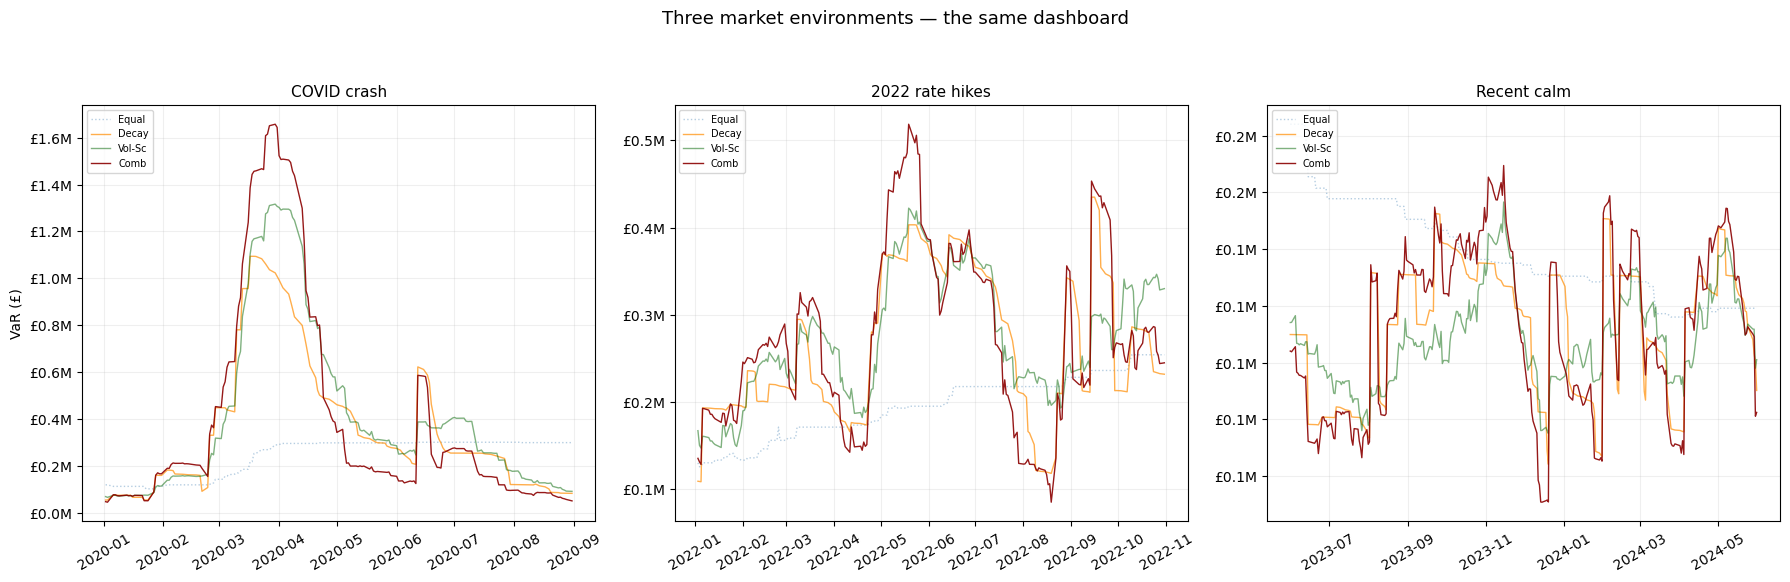

In [7]:
episodes = [
    ("COVID crash", "2020-01-02", "2020-08-31"),
    ("2022 rate hikes", "2022-01-03", "2022-10-31"),
    ("Recent calm", "2023-06-01", "2024-06-01"),
]

fig, axes = plt.subplots(1, 3, figsize=(18, 5.5))

for ax, (title, start, end) in zip(axes, episodes):
    s, e = pd.Timestamp(start), pd.Timestamp(end)
    lighter = [
        (equal, "Equal", "steelblue", 0.4, ":"),
        (decay, "Decay", "darkorange", 0.7, "-"),
        (volscaled, "Vol-Sc", "darkgreen", 0.5, "-"),
        (combined, "Comb", "darkred", 0.9, "-"),
    ]
    for res, label, color, alpha, ls in lighter:
        mask = (res.index >= s) & (res.index <= e)
        ax.plot(res.index[mask], res["VaR"][mask] * POSITION_VALUE,
                linewidth=1.0, color=color, alpha=alpha, linestyle=ls, label=label)
    ax.set_title(title, fontsize=11)
    ax.yaxis.set_major_formatter(plt.FuncFormatter(lambda y, _: f'£{y/1e6:.1f}M'))
    ax.legend(fontsize=7, loc="upper left")
    ax.grid(True, alpha=0.2)
    ax.tick_params(axis='x', rotation=30)

axes[0].set_ylabel(f"VaR (£)")
plt.suptitle("Three market environments — the same dashboard", fontsize=13, y=1.05)
plt.tight_layout()
plt.show()

### What you'd see during each episode

**COVID (left):** All methods spike, but at different speeds. Fast 60d and decay react within days. Equal takes weeks. The combined method sits between decay and vol-scaled. The dash is screaming "something big is happening" — the question is how fast to tighten.

**2022 rate hikes (middle):** A slow grind, not a crash. Decay and equal drift apart gradually. Vol-scaled rises but not dramatically. The signals are weaker — the dashboard says "elevated risk" but not "emergency." You have time to think.

**Recent calm (right):** All methods agree: risk is low. The lines are tightly clustered. The dashboard is boring. That's good — boring means stable. The risk is complacency, not the current exposure.

---

## Part D: The decision framework

Combining all three signals into a decision matrix.

In [8]:
decision_matrix = pd.DataFrame({
    "Risk level": ["Low", "Low", "Elevated", "Elevated", "High", "High"],
    "Ordering signal": ["~1.0", ">1.1", "~1.0", ">1.1", ">1.2", ">1.2"],
    "Shape signal": ["~1.0", "~1.0", ">1.1", ">1.1", ">1.0", ">1.2"],
    "Regime signal": ["~1.0", "<1.2", "<1.2", ">1.2", ">1.5", ">1.5"],
    "Action": [
        "Standard monitoring. Weekly review.",
        "Note elevated recent risk. Watch tomorrow.",
        "Vol regime changing. Review position sizes.",
        "Multiple signals. Tighten limits. Increase monitoring to daily.",
        "Regime shift confirmed. Immediate action: reduce exposure or tighten limits.",
        "CRISIS. Maximum caution. Escalate to desk head. Consider hedging.",
    ],
})
display(decision_matrix.style.hide(axis="index"))

Risk level,Ordering signal,Shape signal,Regime signal,Action
Low,~1.0,~1.0,~1.0,Standard monitoring. Weekly review.
Low,>1.1,~1.0,<1.2,Note elevated recent risk. Watch tomorrow.
Elevated,~1.0,>1.1,<1.2,Vol regime changing. Review position sizes.
Elevated,>1.1,>1.1,>1.2,Multiple signals. Tighten limits. Increase monitoring to daily.
High,>1.2,>1.0,>1.5,Regime shift confirmed. Immediate action: reduce exposure or tighten limits.
High,>1.2,>1.2,>1.5,CRISIS. Maximum caution. Escalate to desk head. Consider hedging.


### The escalation ladder

The dashboard provides an **escalation framework**, not a trading rule:

1. **One signal elevated:** Flag it. Watch tomorrow. Don't act on a single data point.
2. **Two signals elevated:** Review positions. Discuss at morning meeting. Prepare contingency.
3. **Three signals elevated:** Act. Tighten limits or reduce exposure. The dashboard is unanimous.
4. **Signals returning to normal:** Don't rush to reverse. Wait for confirmation. Re-escalation is common.

The key word is **framework**. The dashboard doesn't tell you what to do — it tells you what level of attention the current situation demands.

---

## Part E: Where judgment lives

The dashboard can tell you risk has changed. It cannot tell you why. It cannot tell you what to do. It cannot tell you whether this time is different.

### What numbers can tell you

- Risk has increased/decreased relative to history
- Whether the change is broad (all methods agree) or narrow (one method diverging)
- How fast risk is changing (the slope of the lines)
- Whether breaches are clustering (breach monitoring from notebook 04)

### What numbers cannot tell you

| Question | Why the dashboard can't answer it | Who can |
|----------|----------------------------------|---------|
| "Why is vol rising?" | VaR is descriptive, not causal | You, using market knowledge |
| "Will this get worse?" | All methods are backward-looking | Nobody — but you can assess the situation |
| "Should I hedge or reduce?" | Depends on costs, liquidity, mandate | You, considering business context |
| "Is this a buying opportunity?" | VaR measures risk, not value | You, using investment judgment |
| "Are clients panicking?" | VaR doesn't see flows or behaviour | You, talking to the desk |
| "Is this time different?" | Historical methods assume it isn't | Nobody knows — but you must decide |

### The real job of a risk manager

The dashboard is a tool. The risk manager's actual job is:

1. **Filter signal from noise** — not every dashboard wiggle means something
2. **Calibrate response to context** — a 1.5 ratio during earnings season means something different than a 1.5 ratio during a quiet August
3. **Communicate clearly** — "VaR is up" is useless. "Our £10M SPY position has a 95% VaR of £320K, up from £180K last week, driven by increased volatility in the tech sector" is useful
4. **Know when to override the model** — if you have information the model doesn't (a client is about to close a large position, a Fed announcement is pending), use it
5. **Stay calm when the dashboard is red** — the model panicking doesn't mean you should panic. Someone has to think clearly

The dashboard makes you better at all five. It doesn't replace any of them.

---

## Part F: Honest limitations — what even the complete dashboard misses

After everything we've built, what's still not covered?

In [9]:
final_limitations = pd.DataFrame({
    "What's missing": [
        "Multi-asset / portfolio effects",
        "Intraday risk",
        "Liquidity risk",
        "Tail dependence (copulas)",
        "Forward-looking scenarios",
        "Model risk itself",
    ],
    "Why it matters": [
        "Diversification can reduce VaR by 30-50%. Single-asset VaR overstates portfolio risk.",
        "1-day VaR misses intraday moves. A 5% gap down at open breaches VaR before you can act.",
        "VaR assumes you can exit at the close price. During crises, you can't.",
        "Correlations spike during crises. The diversification you count on evaporates.",
        "Historical methods only see what happened. Stress tests see what could happen.",
        "All methods have assumptions. The assumptions break during crises. You need to know when.",
    ],
})
display(final_limitations.style.hide(axis="index"))

What's missing,Why it matters
Multi-asset / portfolio effects,Diversification can reduce VaR by 30-50%. Single-asset VaR overstates portfolio risk.
Intraday risk,1-day VaR misses intraday moves. A 5% gap down at open breaches VaR before you can act.
Liquidity risk,"VaR assumes you can exit at the close price. During crises, you can't."
Tail dependence (copulas),Correlations spike during crises. The diversification you count on evaporates.
Forward-looking scenarios,Historical methods only see what happened. Stress tests see what could happen.
Model risk itself,All methods have assumptions. The assumptions break during crises. You need to know when.


---

## Key insight

The complete VaR dashboard is not an answer. It's a **structured conversation** between multiple perspectives on risk. Each method sees something different. The divergences are more informative than any single number.

The progression of this project has been:

1. **Single VaR number** → "What's my risk?" (notebook 01)
2. **Rolling VaR** → "How has risk changed?" (notebook 02)
3. **Multiple windows** → "Is the change structural or temporary?" (notebook 03)
4. **Breach analysis** → "When does the model fail?" (notebook 04)
5. **Decay weighting** → "Does recent data tell a different story?" (notebook 05)
6. **Vol scaling** → "Is it just vol or is shape changing?" (notebook 07)
7. **Standardised returns** → "What does the underlying distribution look like?" (notebook 08)
8. **Combined methods** → "What if we fix everything at once?" (notebook 09)
9. **Multi-window dashboard** → "How do windows interact?" (notebook 10)
10. **Complete dashboard** → "How do I use all of this to make decisions?" (this notebook)

The final answer is not a number. It's a way of seeing — multiple lenses on the same data, each catching what the others miss, with the understanding that no lens is complete. The risk manager's job is to look through all of them and decide.